<a href="https://www.kaggle.com/code/krishnabhavani24/ml-miniproject?scriptVersionId=285923087" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

#  Purpose of Dataset(IBM_HR_Analytics_Attrition) [&#129081;](#Top)<a name="ImportLibraries"></a>
*The dataset can help answer the following business questions:*

*Which job roles or departments have higher attrition rates?*

*What demographics (age, gender, marital status) are more prone to attrition?*

*How do work patterns (overtime, distance from home, training) influence attrition?*

*What is the relationship between salary, promotions, performance, and attrition?*

*Which factors contribute most to employee retention strategies?*

# 1. IMPORT LIBRARIES [&#129081;](#Top)<a name="ImportLibraries"></a>

**LIBRARIES:**

* Library **pandas**: to handle data in tabular representation.
* Library **numpy**: for linear algebra routines.
* Library **matplotlib, seaborn**: to visualize data in in plots, graphs and charts.
* library **sklearn** :  It divides your data into independent training and testing subsets to help evaluate a model's performance on unseen data and prevent overfitting. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2 DATA DESCRIPTION AND DATA CLEANING [&#129081;](#Top)<a name="DataExplDataClean"></a>
In this phase, will be performed the exploratory data analysis: data types, missing values, string standardisation, duplicates, measures of the central trend, and relationship detection between fields.

##  Data types [&#129081;](#Top)<a name="DataTypes_df1"></a>

In [2]:

df=pd.read_csv('/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')# load data set

In [3]:
df.head(5) # view the dataset

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


* Check columns data type

In [4]:
df.info() # checking column names and datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

**Data Preproceesing**

In [5]:
df.isnull().sum() #checking for null values

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

##  Remove Duplicates [&#129081;](#Top)<a name="RemDupl_df1"></a>

In [6]:
# Remove duplicates rows
df = df.drop_duplicates().reset_index(drop=True)


In [7]:
import warnings
warnings.filterwarnings('ignore') # Ignore all warnings


In [8]:
df['Attrition'].value_counts() # checking for unique values in attrition


Attrition
No     1233
Yes     237
Name: count, dtype: int64

## 3. Convert into numerical Data types [&#129081;](#Top)<a name="DataTypes_df1"></a>

In [9]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})# to convert categorical data into numerical


In [10]:
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [11]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
# Remove Attrition only if it exists in the list
if 'Attrition' in categorical_cols:
    categorical_cols.remove('Attrition')

categorical_cols

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [12]:
# One-hot encode categorical variables
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)# encoding the data from categorical numerical

In [13]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,1,2,94,3,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,2,3,61,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,4,92,2,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,5,4,56,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,7,1,40,3,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,1,2061,3,41,4,...,True,False,False,False,False,False,False,True,False,False
1466,39,0,613,6,1,1,2062,4,42,2,...,False,False,False,False,False,False,False,True,False,False
1467,27,0,155,4,3,1,2064,2,87,4,...,False,False,True,False,False,False,False,True,False,True
1468,49,0,1023,2,3,1,2065,4,63,2,...,False,False,False,False,False,True,False,True,False,False


In [14]:
numeric_df=df.select_dtypes(include=['number'])
numeric_df.corr()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,-0.159205,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
Attrition,-0.159205,1.000000,-0.056652,0.077924,-0.031373,NaN,-0.010577,-0.103369,-0.006846,-0.130016,...,-0.045872,NaN,-0.137145,-0.171063,-0.059478,-0.063939,-0.134392,-0.160545,-0.033019,-0.156199
DailyRate,0.010661,-0.056652,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,0.077924,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.031373,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.010577,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,-0.103369,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,-0.006846,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,-0.130016,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976


Here Columns like:

* EmployeeCount
* StandardHours
* Over18 (if included)
* EmployeeNumber

are constant for all employees → they have zero variance. so, here we are getting NaN in correlation. so, we have to drop them

In [15]:
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'EmployeeNumber'])


In [16]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,41,4,2,4,...,True,False,False,False,False,False,False,True,False,False
1466,39,0,613,6,1,4,42,2,3,1,...,False,False,False,False,False,False,False,True,False,False
1467,27,0,155,4,3,2,87,4,2,2,...,False,False,True,False,False,False,False,True,False,True
1468,49,0,1023,2,3,4,63,2,2,2,...,False,False,False,False,False,True,False,True,False,False


In [17]:
numeric_df.corr()['Attrition'].sort_values(ascending=False)


Attrition                   1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
EmployeeCount                    NaN
StandardHours                    NaN
N

**Visualization of features correlation with Attrition**

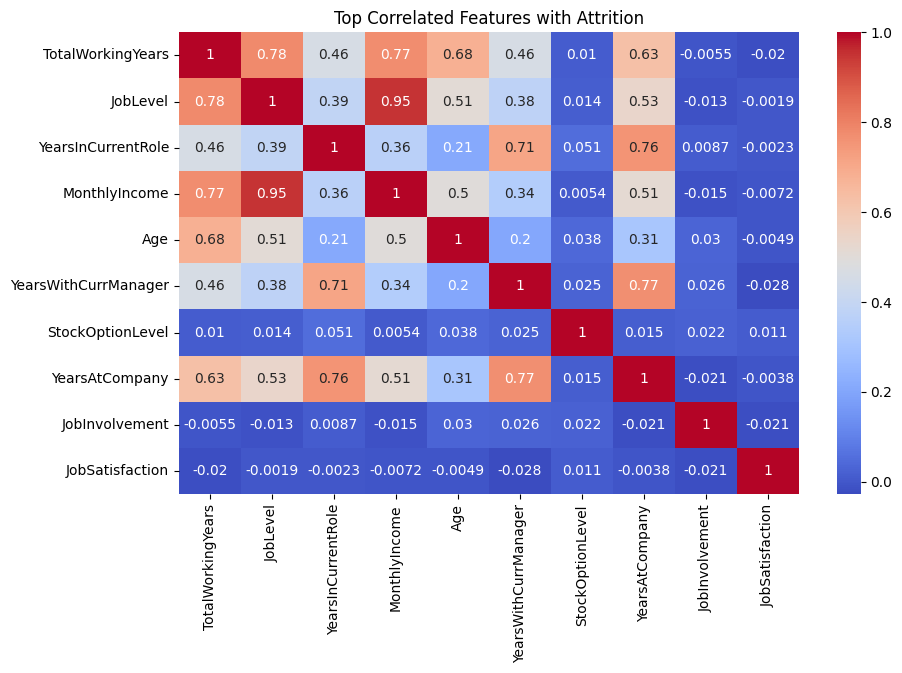

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

top_corr = numeric_df.corr()['Attrition'].abs().sort_values(ascending=False)[1:11].index

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df[top_corr].corr(), annot=True, cmap='coolwarm')
plt.title('Top Correlated Features with Attrition')
plt.show()


# 4. Standardize the data [&#129081;](#Top)<a name="ImportLibraries"></a>

In [19]:
from sklearn.preprocessing import StandardScaler


In [20]:
# Scale numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Attrition')
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


# 5. Exploratory Data Analysis (EDA)[&#129081;](#Top)<a name="ImportLibraries"></a>

In [21]:
import seaborn as sns

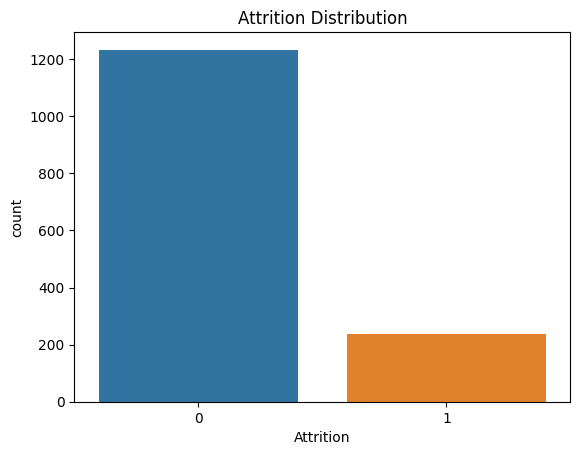

In [22]:

# Attrition distribution
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

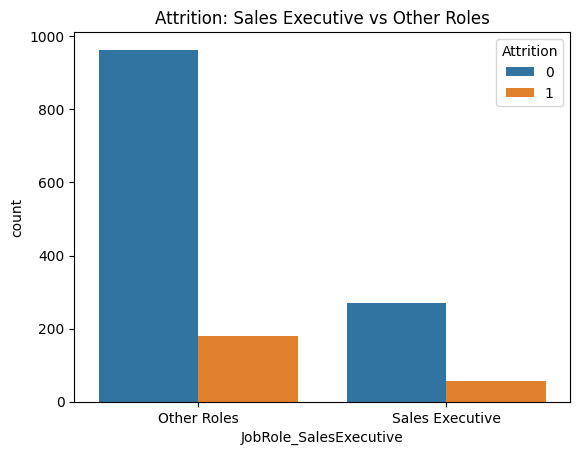

In [23]:
df.rename(columns={'JobRole_Sales Executive': 'JobRole_SalesExecutive'}, inplace=True)

sns.countplot(x='JobRole_SalesExecutive', hue='Attrition', data=df)
plt.title("Attrition: Sales Executive vs Other Roles")
plt.xticks([0, 1], ['Other Roles', 'Sales Executive'])
plt.show()


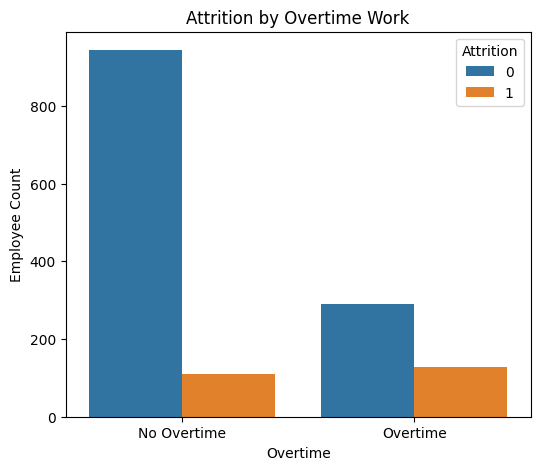

In [24]:
plt.figure(figsize=(6,5))
sns.countplot(x='OverTime_Yes', hue='Attrition', data=df)
plt.title("Attrition by Overtime Work")
plt.xticks([0, 1], ['No Overtime', 'Overtime'])
plt.xlabel("Overtime")
plt.ylabel("Employee Count")
plt.show()


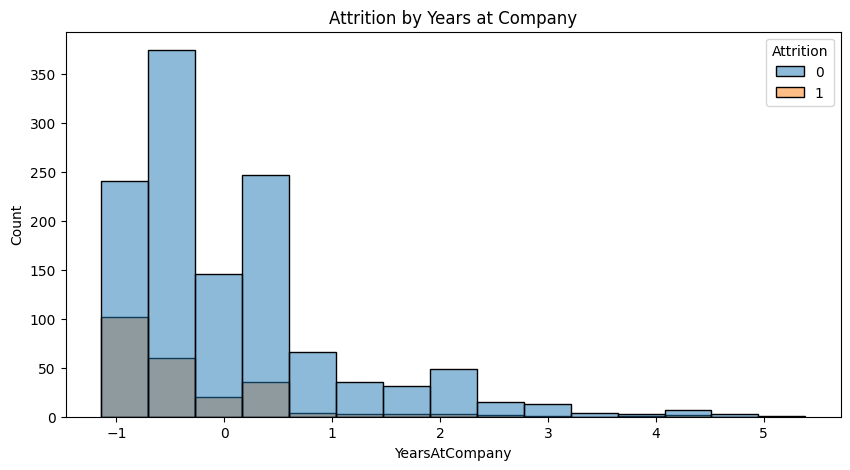

In [25]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='YearsAtCompany', hue='Attrition', bins=15, kde=False)
plt.title("Attrition by Years at Company")
plt.show()


## 6.Insights [&#129081;](#Top)<a name="DataTypes_df1"></a>

In [26]:
# Insights (example)
print("Sample Insights:")
print("1. Employees working overtime are more likely to leave.")
print("2. Low job satisfaction and poor work-life balance correlate with attrition.")
print("3. Lower income employees have higher attrition.")
print("4. Certain roles like Sales Executive have higher attrition rates.")
print("5. Longer tenure reduces likelihood of leaving.")

Sample Insights:
1. Employees working overtime are more likely to leave.
2. Low job satisfaction and poor work-life balance correlate with attrition.
3. Lower income employees have higher attrition.
4. Certain roles like Sales Executive have higher attrition rates.
5. Longer tenure reduces likelihood of leaving.


In [27]:
df.columns

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Res

## 7. Model Building [&#129081;](#Top)<a name="RemDupl_df1"></a>

* Spltiing data into input and output features 

In [28]:
# Split features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [29]:
# Importing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


##  splitting data into train and test set[&#129081;](#Top)<a name="RemDupl_df1"></a>

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


##  Models selection [&#129081;](#Top)<a name="RemDupl_df1"></a>

In [31]:
# Initialize models
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)


**Training the Models**

In [32]:
# Train models
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [33]:
#  Evaluate Models
# =========================
models = {'Logistic Regression': lr, 'Decision Tree': dt, 'Random Forest': rf}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("\n")

=== Logistic Regression ===
Accuracy: 0.8877551020408163
Confusion Matrix:
 [[244  11]
 [ 22  17]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       255
           1       0.61      0.44      0.51        39

    accuracy                           0.89       294
   macro avg       0.76      0.70      0.72       294
weighted avg       0.88      0.89      0.88       294



=== Decision Tree ===
Accuracy: 0.7551020408163265
Confusion Matrix:
 [[215  40]
 [ 32   7]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.84      0.86       255
           1       0.15      0.18      0.16        39

    accuracy                           0.76       294
   macro avg       0.51      0.51      0.51       294
weighted avg       0.77      0.76      0.76       294



=== Random Forest ===
Accuracy: 0.8775510204081632
Confusion Matrix:
 [[254   1]
 [ 35   4]]
Classific

## 8.Logistic Regression ,Decision Tree,Random Forest, with Hyper Parameter Tuning using pipeline[&#129081;](#Top)<a name="RemDupl_df1"></a>

In [34]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore') # Ignore all warnings



In [35]:
lr = LogisticRegression(random_state=42, solver='saga', max_iter=5000)

lr_params = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(lr, lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train, y_train)

print("Best LR Params:", lr_grid.best_params_)
y_pred_lr = lr_grid.predict(X_test)
print("LR Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred_lr))

# ------------------------------
#  Decision Tree with GridSearchCV
# ------------------------------
dt = DecisionTreeClassifier(random_state=42)

dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': [None, 'balanced']
}

dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train, y_train)

print("Best DT Params:", dt_grid.best_params_)
y_pred_dt = dt_grid.predict(X_test)
print("DT Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred_dt))

# ------------------------------
# Random Forest with GridSearchCV
# ------------------------------
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': [None, 'balanced']
}

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)
y_pred_rf = rf_grid.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred_rf))

Best LR Params: {'C': 0.1, 'class_weight': None, 'penalty': 'l2'}
LR Accuracy: 0.8775510204081632
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       255
           1       0.87      0.33      0.48        39

    accuracy                           0.90       294
   macro avg       0.89      0.66      0.71       294
weighted avg       0.90      0.90      0.89       294

Best DT Params: {'class_weight': None, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
DT Accuracy: 0.8775510204081632
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       255
           1       0.50      0.03      0.05        39

    accuracy                           0.87       294
   macro avg       0.68      0.51      0.49       294
weighted avg       0.82      0.87      0.81       294

Best RF Params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_e

## 9. Conclusion [&#129081;](#Top)<a name="RemDupl_df1"></a>

In [36]:
#  Conclusion
# =========================
print("Conclusion:")
print("- Attrition is influenced by overtime, job satisfaction, work-life balance, income, and role.")
print("- logistic Regression usually provides the best prediction accuracy.")
print("- HR can use these insights to reduce attrition by improving employee engagement and compensation strategies.")

Conclusion:
- Attrition is influenced by overtime, job satisfaction, work-life balance, income, and role.
- logistic Regression usually provides the best prediction accuracy.
- HR can use these insights to reduce attrition by improving employee engagement and compensation strategies.


 ## Summary:[&#129081;](#Top)<a name="RemDupl_df1"></a>

**Although Random Forest achieved high accuracy, it performed poorly in identifying employees who left the organization. Logistic Regression achieved the best balance between accuracy and attrition detection, with the highest recall and F1-score for the minority class. Therefore, Logistic Regression is the most suitable model for employee attrition prediction in this dataset.**